<a href="https://colab.research.google.com/github/knight-dev01/MACHING-LEARNING-DEEP-LEARNING-MASTERCLASS-WORKSHOP-2026/blob/main/MACHING_LEARNING_%26_DEEP_LEARNING_MASTERCLASS_WORKSHOP_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# import libraries
# data handling
import pandas as pd
import numpy as np

# visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
np.set_printoptions(precision=3, suppress=True)
# this controls floating point numbers

In [4]:
# tensorflow is a framework for sophisticate AI tasks
import tensorflow as tf
from tensorflow.keras import layers

In [5]:
# get data
import kagglehub

def using_kagglehub():
  path = kagglehub.dataset_download("yasserh/housing-prices-dataset")

  # Linking the scripts to kaggle dataset using pandas
  return pd.read_csv(f"{path}/Housing.csv")

In [6]:
df = using_kagglehub()
# first 5 rows
df.head()

Using Colab cache for faster access to the 'housing-prices-dataset' dataset.


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [7]:
# inspect data EDA (Exploring the data quantitatively)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [8]:
# To show the description of the data
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


<function matplotlib.pyplot.show(close=None, block=None)>

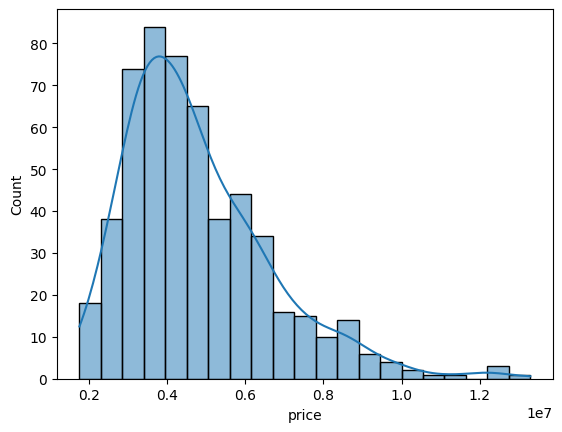

In [9]:
# univariate analysis
sns.histplot(df['price'], kde=True)
plt.show

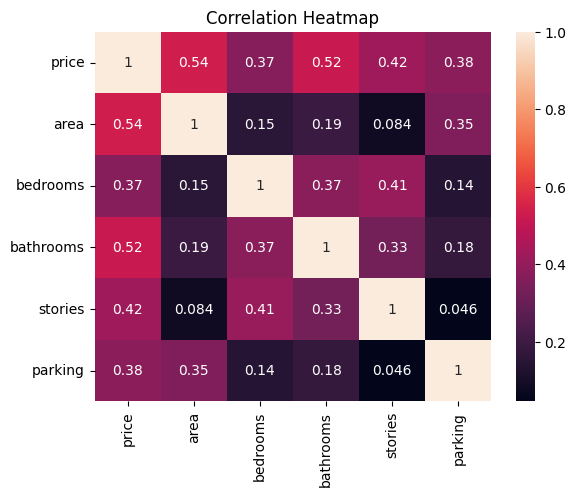

In [10]:
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation Heatmap")
plt.show()

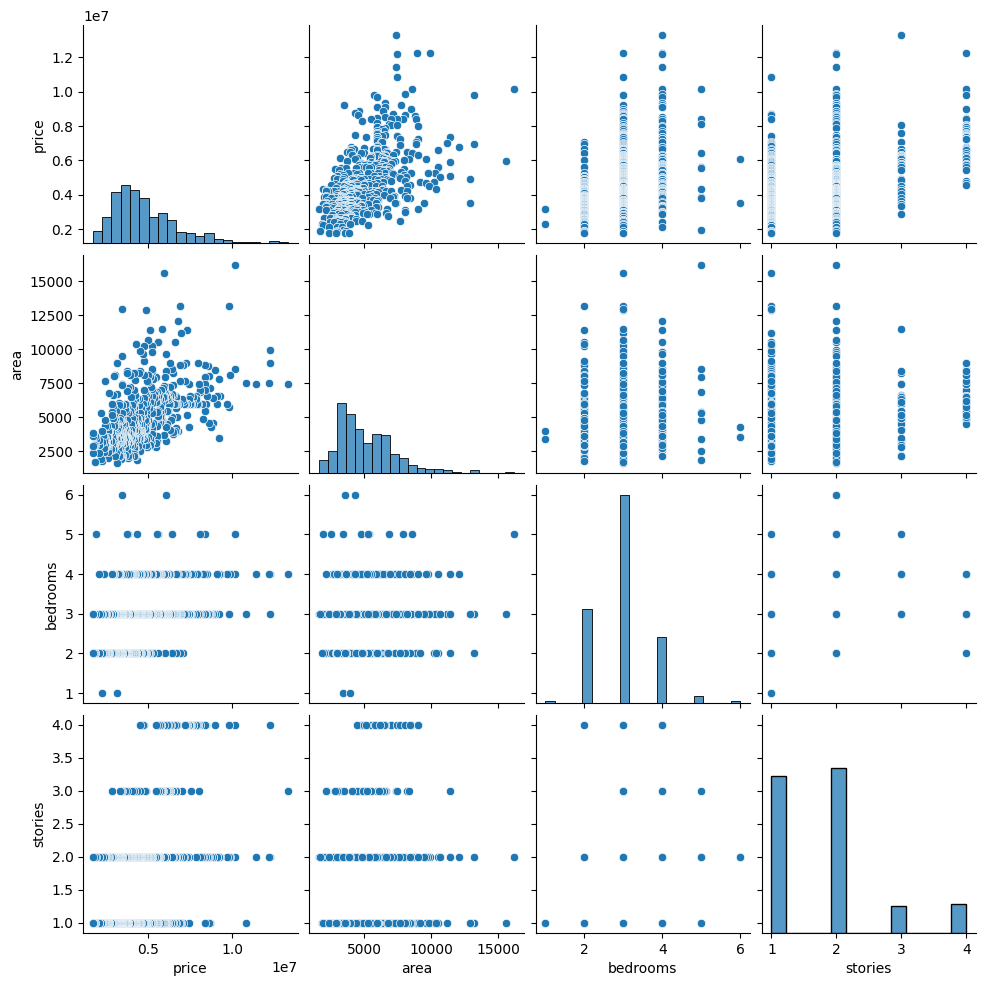

In [11]:
# pairwise comparison
sns.pairplot(df[['price', 'area', 'bedrooms', 'stories']])
plt.show()

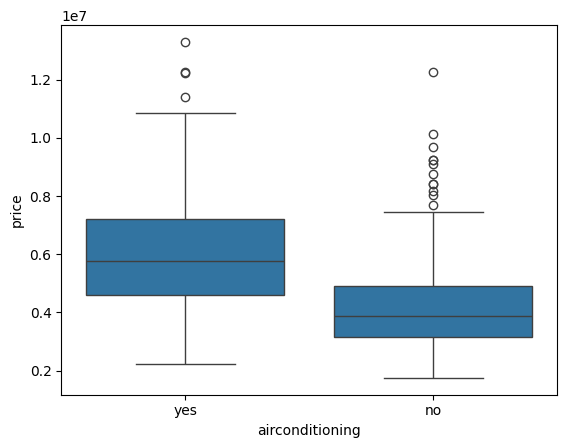

In [12]:
# boxplot
sns.boxplot(x='airconditioning', y='price', data=df)
plt.title
plt.show()

In [13]:
df['furnishingstatus'].value_counts()

,count
furnishingstatus,
semi-furnished,227
unfurnished,178
furnished,140


In [14]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [15]:
object_cols = ['hotwaterheating', 'airconditioning', 'prefarea']

In [16]:
for c in object_cols:
  print(df[c].value_counts())

hotwaterheating
no     520
yes     25
Name: count, dtype: int64
airconditioning
no     373
yes    172
Name: count, dtype: int64
prefarea
no     417
yes    128
Name: count, dtype: int64


In [17]:
binary_cols=['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

# simple mapping
for col in binary_cols:
  df[col] = df[col].map({'yes':1, 'no': 0})
  print(df[col])

0      1
1      1
2      1
3      1
4      1
      ..
540    1
541    0
542    1
543    0
544    1
Name: mainroad, Length: 545, dtype: int64
0      0
1      0
2      0
3      0
4      1
      ..
540    0
541    0
542    0
543    0
544    0
Name: guestroom, Length: 545, dtype: int64
0      0
1      0
2      1
3      1
4      1
      ..
540    1
541    0
542    0
543    0
544    0
Name: basement, Length: 545, dtype: int64
0      0
1      0
2      0
3      0
4      0
      ..
540    0
541    0
542    0
543    0
544    0
Name: hotwaterheating, Length: 545, dtype: int64
0      1
1      1
2      0
3      1
4      1
      ..
540    0
541    0
542    0
543    0
544    0
Name: airconditioning, Length: 545, dtype: int64
0      1
1      0
2      1
3      1
4      0
      ..
540    0
541    0
542    0
543    0
544    0
Name: prefarea, Length: 545, dtype: int64


In [18]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


In [19]:
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True, dtype=int)

In [20]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


In [21]:
# Assignment: Why does drop_first=True drop the first furnishing status column in the data
'''drop_first=True is used in One-Hot Encoding to remove one dummy variable and avoid multicollinearity (dummy variable trap) in Machine Learning models.
This reduces redundancy and improves model efficiency.'''

'drop_first=True is used in One-Hot Encoding to remove one dummy variable and avoid multicollinearity (dummy variable trap) in Machine Learning models.\nThis reduces redundancy and improves model efficiency.'

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   mainroad                         545 non-null    int64
 6   guestroom                        545 non-null    int64
 7   basement                         545 non-null    int64
 8   hotwaterheating                  545 non-null    int64
 9   airconditioning                  545 non-null    int64
 10  parking                          545 non-null    int64
 11  prefarea                         545 non-null    int64
 12  furnishingstatus_semi-furnished  545 non-null    i

In [23]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus_semi-furnished',
       'furnishingstatus_unfurnished'],
      dtype='object')

In [24]:
house_features=df[['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus_semi-furnished',
       'furnishingstatus_unfurnished']]
house_target=df['price']